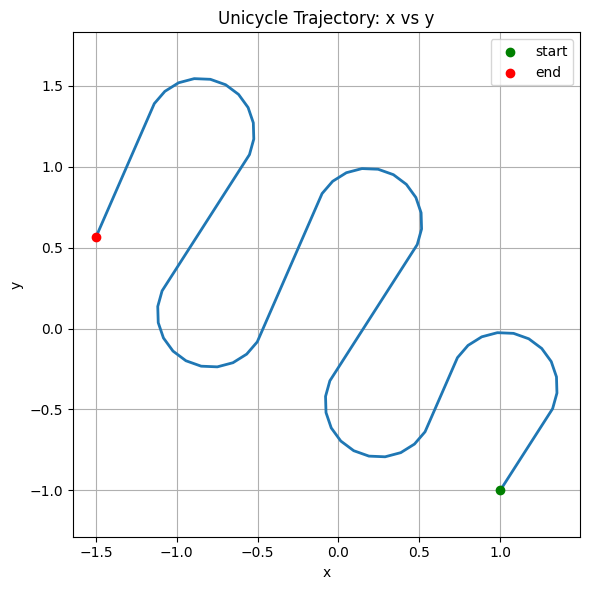

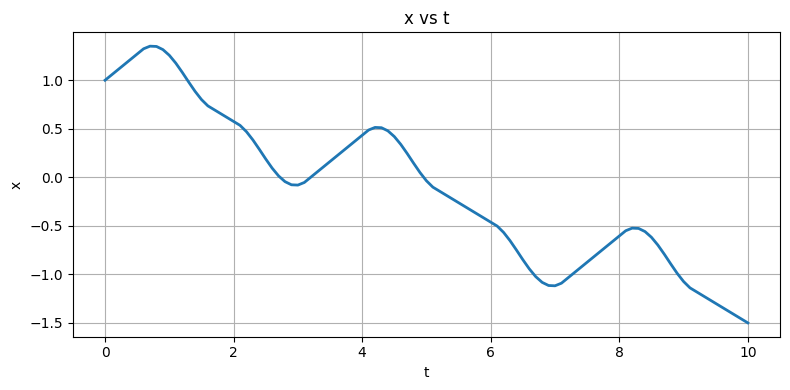

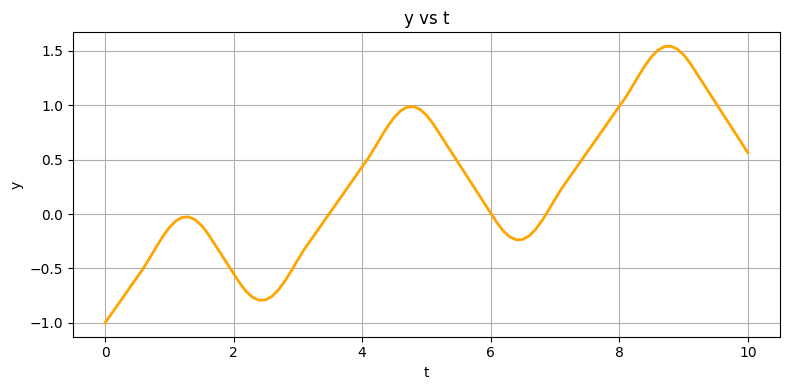

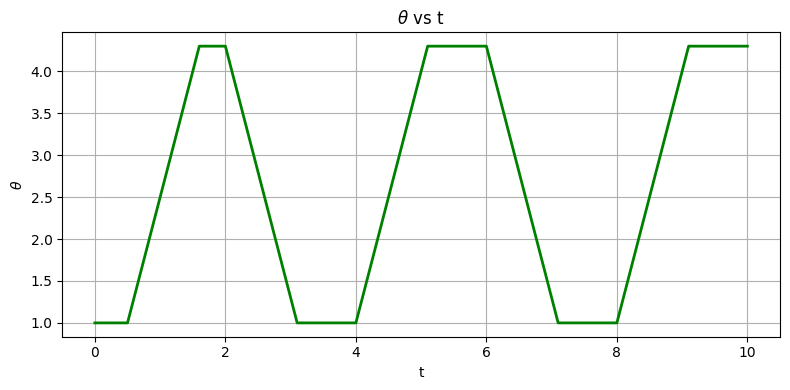

Simulation complete.
Final state: x=-1.4994, y=0.5644, theta=4.3000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML


def v_input(t):
    # Linear velocity control input v(t), v = 1 0 ≤ t ≤ 10
    return 1.0


def omega_input(t):
    # Angular velocity control input omega(t), the conditions here is according to the specifications given on the assignment
    if 0.5 <= t <= 1.5:
        return 3.0
    elif 2.0 <= t <= 3.0:
        return -3.0
    elif 4.0 <= t <= 5.0:
        return 3.0
    elif 6.0 <= t <= 7.0:
        return -3.0
    elif 8.0 <= t <= 9.0:
        return 3.0
    else:
        return 0.0


def unicycle_dynamics(state, v, omega):
  #  Unicycle Continuous-time dynamics: returns [xdot, ydot, thetadot]
  # From Equation 2 of the Homework 1 pdf
    x, y, theta = state
    xdot = v * np.cos(theta)
    ydot = v * np.sin(theta)
    thetadot = omega
    return np.array([xdot, ydot, thetadot])


def simulate_euler(t0, tf, dt, x0):
    # Euler integration of the unicycle model
    n_steps = int(round((tf - t0) / dt)) + 1
    t = np.linspace(t0, tf, n_steps)

    x = np.zeros(n_steps)
    y = np.zeros(n_steps)
    theta = np.zeros(n_steps)
    # Initializing with initial conditions mentioned on the assignment
    x[0], y[0], theta[0] = x0

    for k in range(n_steps - 1):
        v_k = v_input(t[k])
        omega_k = omega_input(t[k])

        state_k = np.array([x[k], y[k], theta[k]])
        deriv = unicycle_dynamics(state_k, v_k, omega_k)

        state_next = state_k + dt * deriv
        x[k + 1], y[k + 1], theta[k + 1] = state_next

    return t, x, y, theta


#  Run simulation
# Conditions mentioned on the assignment
t0, tf, dt = 0.0, 10.0, 0.1
x0 = (1.0, -1.0, 1.0)  # x(0), y(0), theta(0)
t, x, y, theta = simulate_euler(t0, tf, dt, x0)
# Solution of 2(a)
# Plot 1: x vs y
plt.figure(figsize=(6, 6))
plt.plot(x, y, linewidth=2)
plt.scatter([x[0]], [y[0]], color="green", zorder=5, label="start")
plt.scatter([x[-1]], [y[-1]], color="red", zorder=5, label="end")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Unicycle Trajectory: x vs y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: x vs t
plt.figure(figsize=(8, 4))
plt.plot(t, x, linewidth=2)
plt.xlabel("t")
plt.ylabel("x")
plt.title("x vs t")
plt.grid(True)
plt.tight_layout()
plt.show()
# Plot 3: y vs t
plt.figure(figsize=(8, 4))
plt.plot(t, y, linewidth=2, color="orange")
plt.xlabel("t")
plt.ylabel("y")
plt.title("y vs t")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 4: theta vs t
plt.figure(figsize=(8, 4))
plt.plot(t, theta, linewidth=2, color="green")
plt.xlabel("t")
plt.ylabel(r"$\theta$")
plt.title(r"$\theta$ vs t")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Simulation complete.")
print(f"Final state: x={x[-1]:.4f}, y={y[-1]:.4f}, theta={theta[-1]:.4f}")

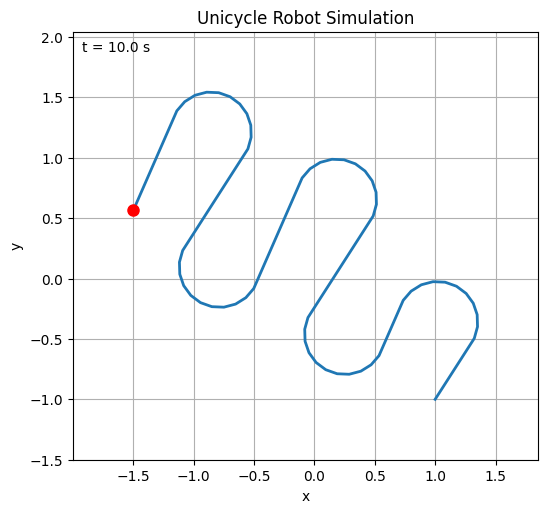

In [5]:
# Solution of 2(b)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)
ax.set_aspect("equal")
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Unicycle Robot Simulation")

trail_line, = ax.plot([], [], color="tab:blue", linewidth=2)
robot_point, = ax.plot([], [], "o", color="red", markersize=8)
time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, verticalalignment="top")

for frame in range(len(x)):
    trail_line.set_data(x[:frame + 1], y[:frame + 1])
    robot_point.set_data([x[frame]], [y[frame]])
    time_text.set_text(f"t = {t[frame]:.1f} s")

    clear_output(wait=True)
    display(fig)

plt.close(fig)

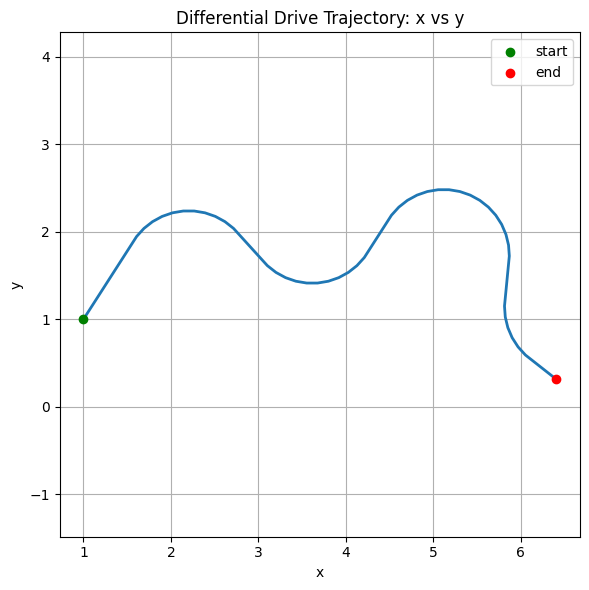

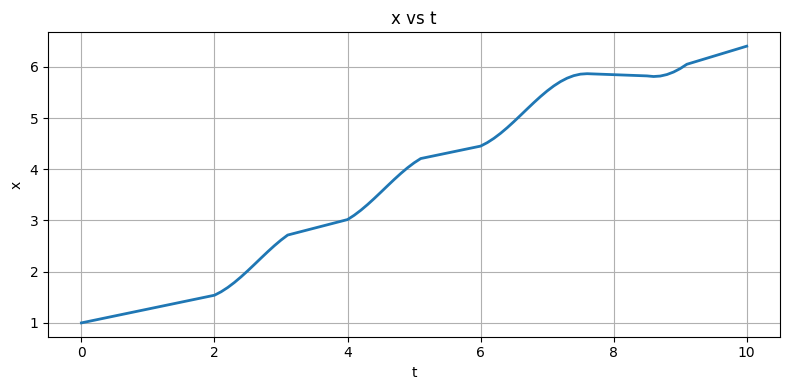

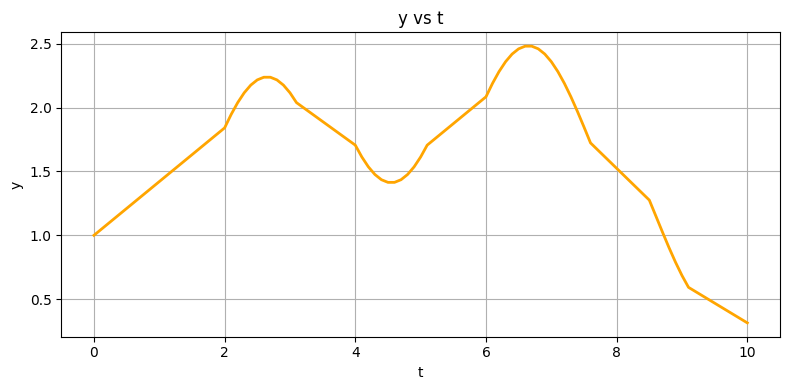

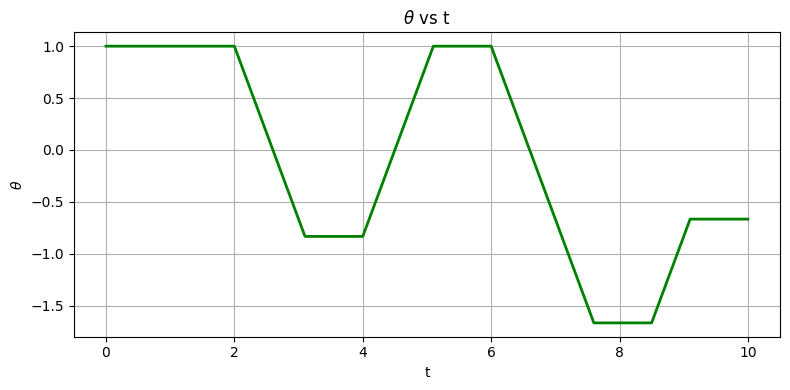

Final state: x=6.4048, y=0.3142, theta=-0.6667


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Given Robot parameters
r = 0.1   # wheel radius
L = 0.9   # distance between wheels


def omega_l_input(t):
    # Left wheel angular velocity control input, , the conditions here is according to the specifications given on the assignment
    if 2.0 <= t <= 3.0:
        return 20.0
    elif 6.0 <= t <= 7.5:
        return 20.0
    else:
        return 5.0


def omega_r_input(t):
    # Right wheel angular velocity control input, the conditions here is according to the specifications given on the assignment
    if 4.0 <= t <= 5.0:
        return 20.0
    elif 8.5 <= t <= 9.0:
        return 20.0
    else:
        return 5.0


def diff_drive_dynamics(state, omega_l, omega_r, r, L):
   # From Equation 4 of the Homework 1 pdf
    x, y, theta = state
    xdot = (r / 2.0) * np.cos(theta) * omega_l + (r / 2.0) * np.cos(theta) * omega_r
    ydot = (r / 2.0) * np.sin(theta) * omega_l + (r / 2.0) * np.sin(theta) * omega_r
    thetadot = -(r / L) * omega_l + (r / L) * omega_r
    return np.array([xdot, ydot, thetadot])


def simulate_euler(t0, tf, dt, x0, r, L):
    n_steps = int(round((tf - t0) / dt)) + 1
    t = np.linspace(t0, tf, n_steps)

    x = np.zeros(n_steps)
    y = np.zeros(n_steps)
    theta = np.zeros(n_steps)
    # Initializing with initial conditions mentioned on the assignment

    x[0], y[0], theta[0] = x0

    for k in range(n_steps - 1):
        wl_k = omega_l_input(t[k])
        wr_k = omega_r_input(t[k])

        state_k = np.array([x[k], y[k], theta[k]])
        deriv = diff_drive_dynamics(state_k, wl_k, wr_k, r, L)

        state_next = state_k + dt * deriv
        x[k + 1], y[k + 1], theta[k + 1] = state_next

    return t, x, y, theta

def init():
    trail_line.set_data([], [])
    robot_point.set_data([], [])
    time_text.set_text("")
    return trail_line, robot_point, time_text


def update(frame):
    trail_line.set_data(x[:frame + 1], y[:frame + 1])
    robot_point.set_data([x[frame]], [y[frame]])
    time_text.set_text(f"t = {t[frame]:.1f} s")
    return trail_line, robot_point, time_text


#  Run simulation
# Conditions mentioned on the assignment
t0, tf, dt = 0.0, 10.0, 0.1
x0 = (1.0, 1.0, 1.0)  # x(0), y(0), theta(0)

t, x, y, theta = simulate_euler(t0, tf, dt, x0, r, L)
# Solution of 3(a)
# Plot 1: x vs y
plt.figure(figsize=(6, 6))
plt.plot(x, y, linewidth=2)
plt.scatter([x[0]], [y[0]], color="green", zorder=5, label="start")
plt.scatter([x[-1]], [y[-1]], color="red", zorder=5, label="end")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Differential Drive Trajectory: x vs y")
plt.axis("equal"); plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: x vs t
plt.figure(figsize=(8, 4))
plt.plot(t, x, linewidth=2)
plt.xlabel("t"); plt.ylabel("x")
plt.title("x vs t"); plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: y vs t
plt.figure(figsize=(8, 4))
plt.plot(t, y, linewidth=2, color="orange")
plt.xlabel("t"); plt.ylabel("y")
plt.title("y vs t"); plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 4: theta vs t
plt.figure(figsize=(8, 4))
plt.plot(t, theta, linewidth=2, color="green")
plt.xlabel("t"); plt.ylabel(r"$\theta$")
plt.title(r"$\theta$ vs t"); plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final state: x={x[-1]:.4f}, y={y[-1]:.4f}, theta={theta[-1]:.4f}")

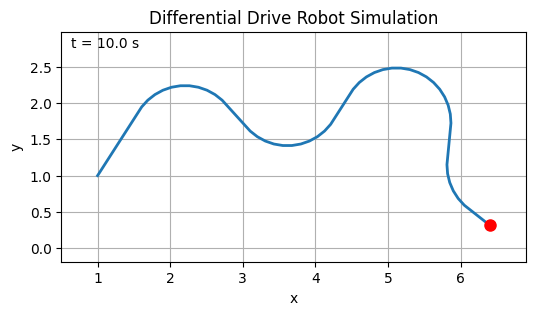

In [7]:
# Solution of 3(b)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)
ax.set_aspect("equal")
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Differential Drive Robot Simulation")

trail_line, = ax.plot([], [], color="tab:blue", linewidth=2)
robot_point, = ax.plot([], [], "o", color="red", markersize=8)
time_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, verticalalignment="top")

for frame in range(len(x)):
    trail_line.set_data(x[:frame + 1], y[:frame + 1])
    robot_point.set_data([x[frame]], [y[frame]])
    time_text.set_text(f"t = {t[frame]:.1f} s")

    clear_output(wait=True)
    display(fig)

plt.close(fig)